In [34]:
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
import numpy as np
from qiskit.circuit import QuantumRegister
from qiskit.circuit.library import QFTGate
from qiskit.circuit.library import HGate, CXGate, XGate, MCXGate, QFTGate, CRZGate
from qiskit import ClassicalRegister, transpile
from qiskit_aer import AerSimulator
import numpy as np
# Order of qubits
# 0: c0
# 1: c1
# 2 ... 2+y_qubits-1: y
# 2+y_qubits ... : x


def make_position_registers(nx = 4,ny = 4):
    x_qubits = int(np.ceil(np.log2(nx)))
    y_qubits = int(np.ceil(np.log2(ny)))

    registers_x = [QuantumRegister(1, name=f"x{i}") for i in range(x_qubits)]
    registers_y = [QuantumRegister(1, name=f"y{i}") for i in range(y_qubits)]

    return registers_x,registers_y

def make_reflector(qc,nx,ny):
    x_qubits = int(np.ceil(np.log2(nx)))
    y_qubits = int(np.ceil(np.log2(ny)))

    reflect_left2right = XGate().control(x_qubits+1,None,'0' +''.join(['0']*x_qubits))
    reflect_right2left = XGate().control(x_qubits+1,None,'0' +''.join(['1']*x_qubits))
    reflect_top2bot = XGate().control(y_qubits+1,None,'1' + ''.join(['0']*y_qubits))
    reflect_bot2top = XGate().control(y_qubits+1,None,'1' + ''.join(['1']*y_qubits))

    qc.append(reflect_left2right,list(np.arange(x_qubits+y_qubits+2,y_qubits+2,-1).astype(int)-1)+[1,0]) # x qubits left to right
    qc.append(reflect_right2left,list(np.arange(x_qubits+y_qubits+2,y_qubits+2,-1).astype(int)-1)+[1,0]) # x qubits right to left

    qc.append(reflect_top2bot,list(np.arange(y_qubits+2,2,-1).astype(int)-1)+[1,0]) # y qubits top to bot
    qc.append(reflect_bot2top,list(np.arange(y_qubits+2,2,-1).astype(int)-1)+[1,0]) # y qubits bot to top

    return qc

import numpy as np
from qiskit.circuit.library import QFTGate, PhaseGate

def qft_adder(qc, nx, ny):

    x_qubits = int(np.ceil(np.log2(nx)))
    y_qubits = int(np.ceil(np.log2(ny)))

    c0 = 0
    c1 = 1

    x_inds = list(np.arange(x_qubits + y_qubits + 2, y_qubits + 2, -1).astype(int) - 1)[::-1]
    y_inds = list(np.arange(y_qubits + 2, 2, -1).astype(int) - 1)[::-1]

    qft_x = QFTGate(num_qubits=x_qubits)
    qft_x_dg = QFTGate(num_qubits=x_qubits).inverse()

    qft_y = QFTGate(num_qubits=y_qubits)
    qft_y_dg = QFTGate(num_qubits=y_qubits).inverse()

    qc.append(qft_x, x_inds)
    qc.append(qft_y, y_inds)

    theta_x = 2 * np.pi / (2 ** np.arange(1, x_qubits + 1))
    theta_y = 2 * np.pi / (2 ** np.arange(1, y_qubits + 1))

    # controls ordered as [c1, c0]
    controls = [c1, c0]

    # c1 c0 = 01: x += 1
    for i, q in enumerate(x_inds):
        gate = PhaseGate(theta_x[i]).control(2, ctrl_state='01')
        qc.append(gate, controls + [q])

    # c1 c0 = 00: x -= 1
    for i, q in enumerate(x_inds):
        gate = PhaseGate(-theta_x[i]).control(2, ctrl_state='00')
        qc.append(gate, controls + [q])

    # c1 c0 = 11: y += 1
    for i, q in enumerate(y_inds):
        gate = PhaseGate(theta_y[i]).control(2, ctrl_state='11')
        qc.append(gate, controls + [q])

    # c1 c0 = 10: y -= 1
    for i, q in enumerate(y_inds):
        gate = PhaseGate(-theta_y[i]).control(2, ctrl_state='10')
        qc.append(gate, controls + [q])

    qc.append(qft_x_dg, x_inds)
    qc.append(qft_y_dg, y_inds)

    return qc

import numpy as np
from qiskit.circuit.library import RYGate

import numpy as np
from qiskit.circuit.library import HGate

def make_position_dependent_scatter_coin(qc, nx, ny, pxy_water):
    x_qubits = int(np.ceil(np.log2(nx)))
    y_qubits = int(np.ceil(np.log2(ny)))

    c0 = 0
    c1 = 1

    y_ctrls = list(np.arange(y_qubits + 2, 2, -1).astype(int) - 1)
    x_ctrls = list(np.arange(x_qubits + y_qubits + 2, y_qubits + 2, -1).astype(int) - 1)

    pos_ctrls = y_ctrls + x_ctrls
    n_controls = len(pos_ctrls)


    for y in range(ny):
        for x in range(nx):

            if pxy_water[y, x] == 0:
                continue

            y_bits = format(y, f"0{y_qubits}b")
            x_bits = format(x, f"0{x_qubits}b")
            ctrl_state = y_bits + x_bits

            H_pos = HGate().control(n_controls, ctrl_state=ctrl_state)

            # activate scatter coin only at this position
            qc.append(H_pos, pos_ctrls + [c0])
            qc.append(H_pos, pos_ctrls + [c1])

    return qc


def add_position_measurements(qc, nx, ny):
    x_qubits = int(np.ceil(np.log2(nx)))
    y_qubits = int(np.ceil(np.log2(ny)))

    y_inds = list(np.arange(y_qubits + 2, 2, -1).astype(int) - 1)[::-1]
    x_inds = list(np.arange(x_qubits + y_qubits + 2, y_qubits + 2, -1).astype(int) - 1)[::-1]

    c_pos = ClassicalRegister(x_qubits + y_qubits, "pos")
    qc.add_register(c_pos)

    # measure y then x
    qc.measure(y_inds + x_inds, c_pos)

    return qc
def score_detector_response(counts, nx, ny, detector_xy):

    # from the histogram, simply isolate the detector locations
    x_qubits = int(np.ceil(np.log2(nx)))
    y_qubits = int(np.ceil(np.log2(ny)))

    det_x, det_y = detector_xy
    total = sum(counts.values())

    detector_hits = 0

    for bitstring, count in counts.items():
        bits = bitstring.replace(" ", "")

        y_bits = bits[:y_qubits]
        x_bits = bits[y_qubits:y_qubits + x_qubits]

        y = int(y_bits, 2)
        x = int(x_bits, 2)

        if x == det_x and y == det_y:
            detector_hits += count

    return detector_hits / total


def score_multiple_detectors(counts, nx, ny, detector_list):
    return {
        (x, y): score_detector_response(counts, nx, ny, (x, y))
        for x, y in detector_list
    }


def score_edge_detector_array(counts, nx, ny, edge='right', length=3, offset=0):
    """
    Returns an array of probabilities for each pixel in the detector.

    edge: 'left', 'right', 'top', 'bottom'
    length: number of pixels (e.g. 3)
    offset: starting index along the edge
    """

    x_qubits = int(np.ceil(np.log2(nx)))
    y_qubits = int(np.ceil(np.log2(ny)))

    total = sum(counts.values())

    # initialize detector array
    detector_array = np.zeros(length)

    for bitstring, count in counts.items():
        bits = bitstring.replace(" ", "")

        y_bits = bits[:y_qubits]
        x_bits = bits[y_qubits:y_qubits + x_qubits]

        y = int(y_bits, 2)
        x = int(x_bits, 2)

        if edge == 'right':
            if x == nx - 1 and offset <= y < offset + length:
                detector_array[y - offset] += count

        elif edge == 'left':
            if x == 0 and offset <= y < offset + length:
                detector_array[y - offset] += count

        elif edge == 'top':
            if y == ny - 1 and offset <= x < offset + length:
                detector_array[x - offset] += count

        elif edge == 'bottom':
            if y == 0 and offset <= x < offset + length:
                detector_array[x - offset] += count

    # convert to probabilities
    detector_array = detector_array #/ total

    return detector_array

def score_all_edge_detector_arrays(counts, nx, ny, length=3):
    return {
        "right": score_edge_detector_array(counts, nx, ny, 'right', length),
        "left": score_edge_detector_array(counts, nx, ny, 'left', length),
        "top": score_edge_detector_array(counts, nx, ny, 'top', length),
        "bottom": score_edge_detector_array(counts, nx, ny, 'bottom', length),
    }

def make_walk_circuit(nx, ny, pxy_water, n_steps):
    register_x, register_y = make_position_registers(nx=nx, ny=ny)

    qcoin0 = QuantumRegister(1, "c0")
    qcoin1 = QuantumRegister(1, "c1")

    qc = QuantumCircuit(qcoin0, qcoin1, *register_y, *register_x)

    for _ in range(n_steps):
        qc = make_position_dependent_scatter_coin(qc, nx, ny, pxy_water)
        qc = make_reflector(qc, nx, ny)
        qc = qft_adder(qc, nx, ny)

    qc = add_position_measurements(qc, nx, ny)

    return qc

### Making world containing scattering medium in a square from  x=1,y=1 to x=3,y=3

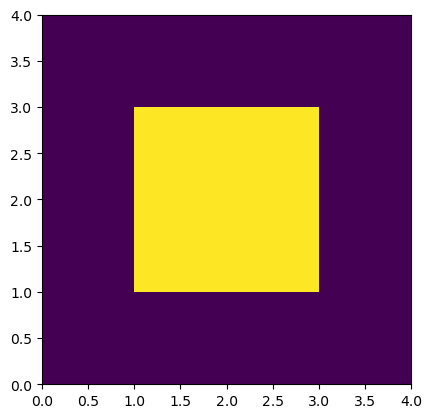

In [41]:
nx, ny = 4,4

pxy_water = np.zeros((ny, nx))
pxy_water[1:3, 1:3] = 0.25
plt.imshow(pxy_water, origin='lower', extent=(0, nx, 0, ny))
qc = make_walk_circuit(nx, ny, pxy_water, n_steps=100)


### Making circuit to simulate photon coherent scatter

In [43]:
# 1 iteration
qc = make_walk_circuit(nx, ny, pxy_water, n_steps=100)
# # plt.figure(figsize=(6, 3))
# qc.draw(output="mpl",reverse_bits=True)
# qc.draw(output="mpl",reverse_bits=True)
# Choose the backend

### Simulation 

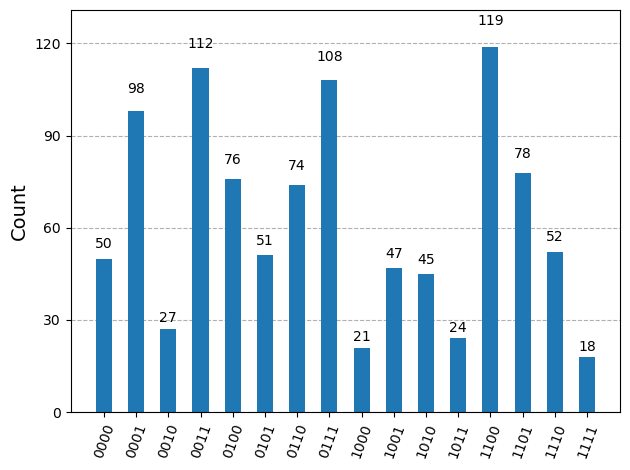

In [44]:
from qiskit import transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram


backend = AerSimulator()

# Transpile the circuit for this specific backend
# This step is critical for Aer to understand the circuit instructions
# The simulator cannot run without transpilation
tsp_circuit = transpile(qc, backend)

# Break open the abstract blocks using .decompose()
#decom_circuit = full_circuit.decompose()
tsp_circuit.draw(output = 'mpl')
job = backend.run(tsp_circuit, shots=1000) # 1000 shots
result = job.result()
counts = result.get_counts()

# Plot the histogram
plot_histogram(counts)

### Detector Array photon normalized counts

{'right': array([0.457, 0.   , 0.   , 0.   ]), 'left': array([0., 0., 0., 0.]), 'top': array([0., 0., 0., 0.]), 'bottom': array([0.   , 0.   , 0.214, 0.129])}


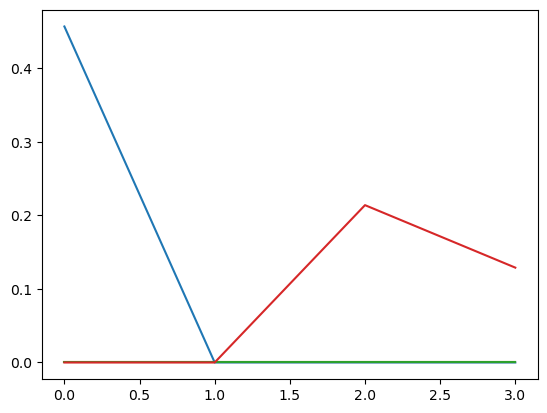

In [5]:
responses = score_all_edge_detector_arrays(counts, nx, ny, length=4)
print(responses)
for edge, response in responses.items():
    plt.plot(responses[edge], label=edge)
plt.show()

### Importing Qiskit to QASM to run in IBM cloud

In [6]:
from qiskit import transpile
from qiskit import qasm3

qc_decomposed = transpile(qc, basis_gates=['u', 'cx'])

qasm_str = qasm3.dumps(qc_decomposed)



In [7]:
qc_demo_decomposed = transpile(qc, basis_gates=['u', 'cx'])
qasm_str_demo = qasm3.dumps(qc_demo_decomposed)

import os
print(os.getcwd())
with open("./circuit_demo.qasm", "w") as f:
    f.write(qasm_str_demo)


c:\Users\maliakal\Desktop\QCProject


In [9]:
from qiskit_ibm_runtime import QiskitRuntimeService

QiskitRuntimeService.save_account(
token="E6mppNQwhvHKmss0P_k-Xn-WCSwK-h7KccYFCnNOKlKt", # Use the 44-character API_KEY you created and saved from the IBM Quantum Platform Home dashboard
instance="crn:v1:bluemix:public:quantum-computing:us-east:a/1cdebb7172a3417694eb3decda39a8ed:7858bc0b-d4c4-4444-8986-bd7a2510d73b::", overwrite=True # Optional
)
# Run every time you need the service


In [10]:
service = QiskitRuntimeService()

Using backend: ibm_fez
Original depth: 526
ISA depth: 59655
Qubits: 156
Job ID: d7q09n9oagoc73firk80
{'0010': 286, '0100': 183, '0111': 276, '1110': 260, '1000': 237, '1001': 259, '0011': 292, '1111': 261, '1011': 248, '1100': 264, '0000': 248, '0101': 207, '0110': 262, '1101': 279, '0001': 290, '1010': 244}


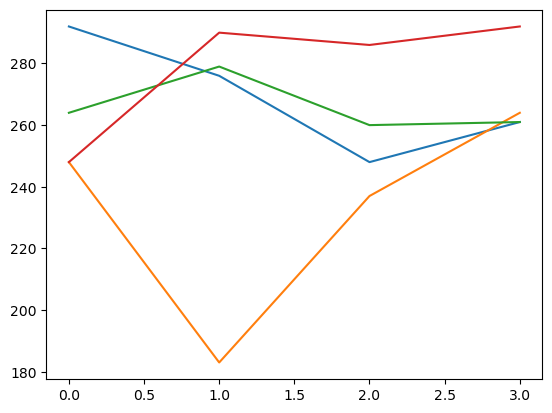

Using backend: ibm_fez
Original depth: 1051
ISA depth: 119454
Qubits: 156
Job ID: d7q09t9oagoc73firkj0
{'0001': 254, '0101': 214, '1101': 275, '1001': 239, '1100': 238, '0111': 266, '0110': 271, '1011': 277, '1000': 197, '1111': 307, '0000': 240, '1010': 247, '1110': 271, '0011': 301, '0100': 200, '0010': 299}


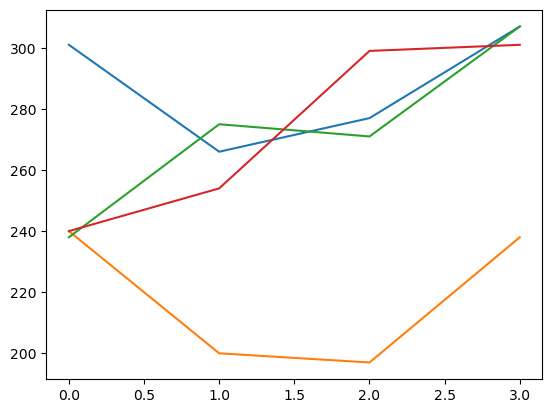

In [48]:
from qiskit import qasm3 as qasm2
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler

# 1. Load your QASM circuit
# qc = qasm2.load("circuit_demo.qasm")

# 2. Connect to IBM
service = QiskitRuntimeService()


# 3. use a loop to vary the number of steps to try out different ISA depths and see how it affects the time taken

for n_steps in [25,50]:
    qc = make_walk_circuit(nx, ny, pxy_water, n_steps=n_steps)

    # 3. Pick a real backend
    backend = service.least_busy(
        simulator=False,
        operational=True,
        min_num_qubits=qc.num_qubits
    )

    print("Using backend:", backend.name)

    # 4. Convert your circuit to the machine's ISA
    pm = generate_preset_pass_manager(
        backend=backend,
        optimization_level=1
    )
    isa_circuit = pm.run(qc)

    print("Original depth:", qc.depth())
    print("ISA depth:", isa_circuit.depth())
    print("Qubits:", isa_circuit.num_qubits)

    # 5. Run with Sampler
    sampler = Sampler(mode=backend)
    sampler.options.default_shots = 4096

    job = sampler.run([isa_circuit])
    print("Job ID:", job.job_id())

    # 6. Get counts
    result = job.result()
    pub_result = result[0]

    counts = pub_result.data.pos.get_counts()
    print(counts)
    
    responses = score_all_edge_detector_arrays(counts, nx, ny, length=4)
    # print(responses)
    
    for edge, response in responses.items():
        plt.plot(responses[edge], label=edge)
    plt.show()

In [ ]:
responses = score_all_edge_detector_arrays(counts, nx, ny, length=4)
print(responses)
for edge, response in responses.items():
    plt.plot(responses[edge], label=edge)
plt.show()